=== Memproses Bagian A: Sinyal 1D ===


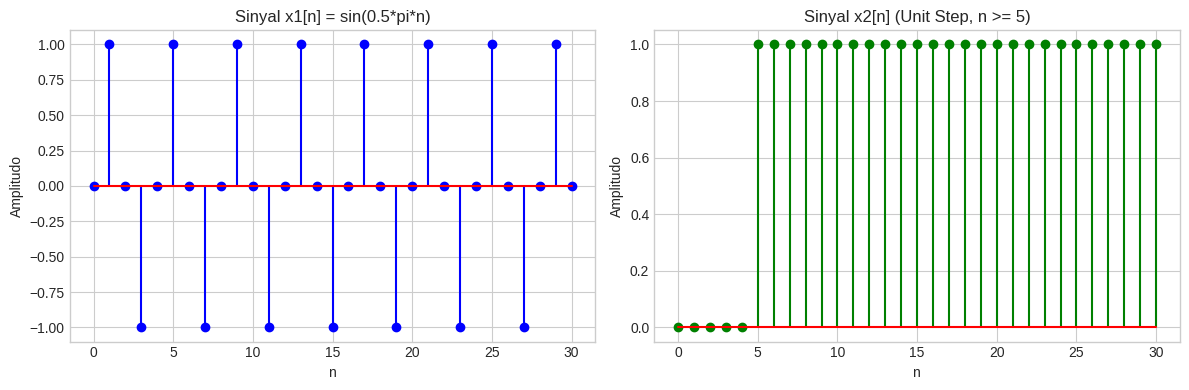

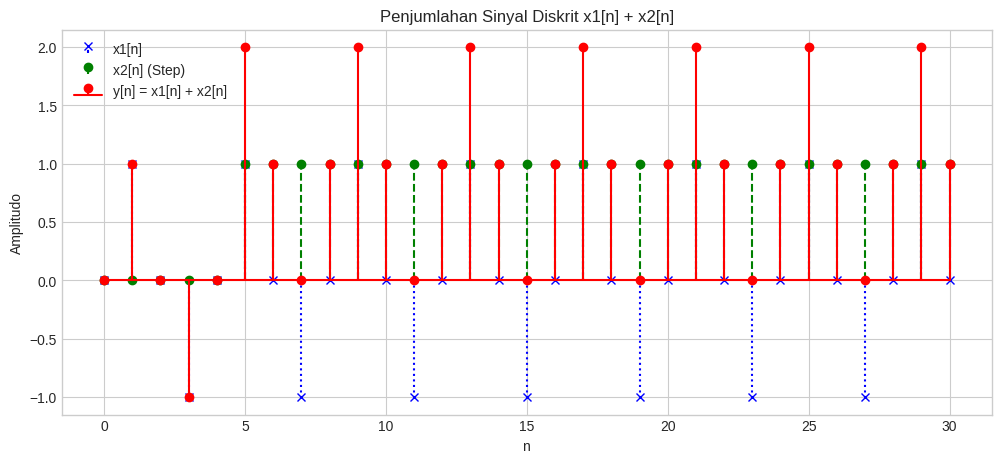

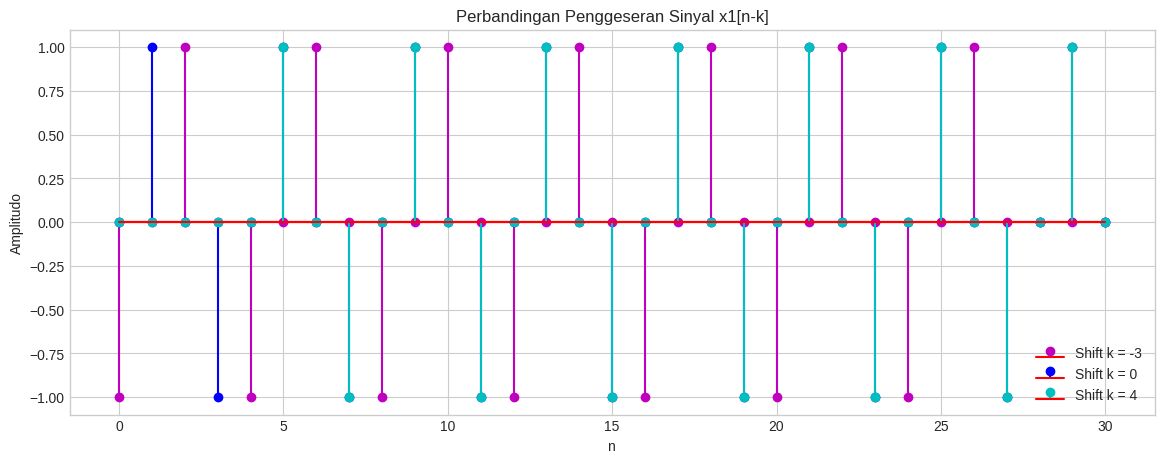

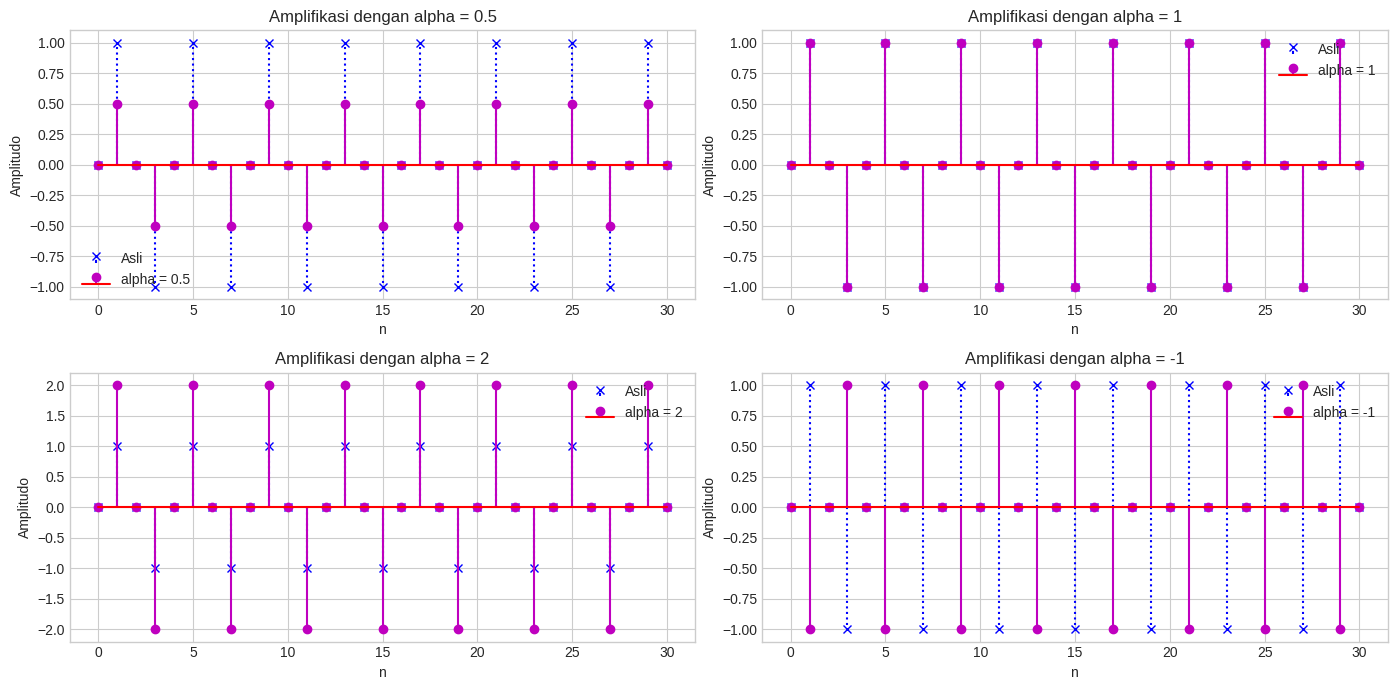


=== Memproses Bagian B: Citra 2D ===
Properti Citra Asli -> Ukuran: (300, 300) | Tipe Data: uint8
Nilai Piksel -> Min: 0, Max: 255


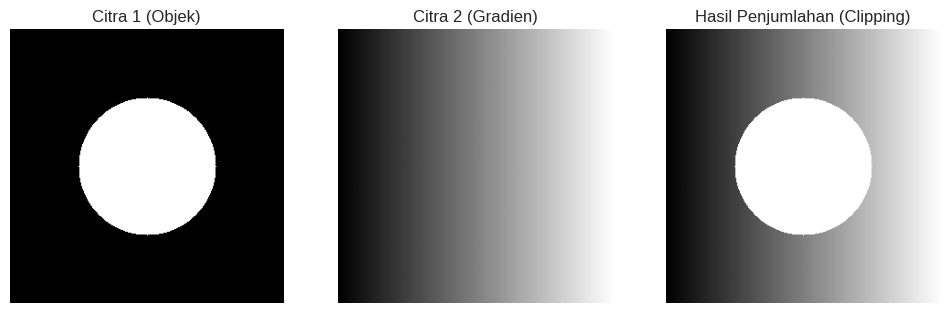

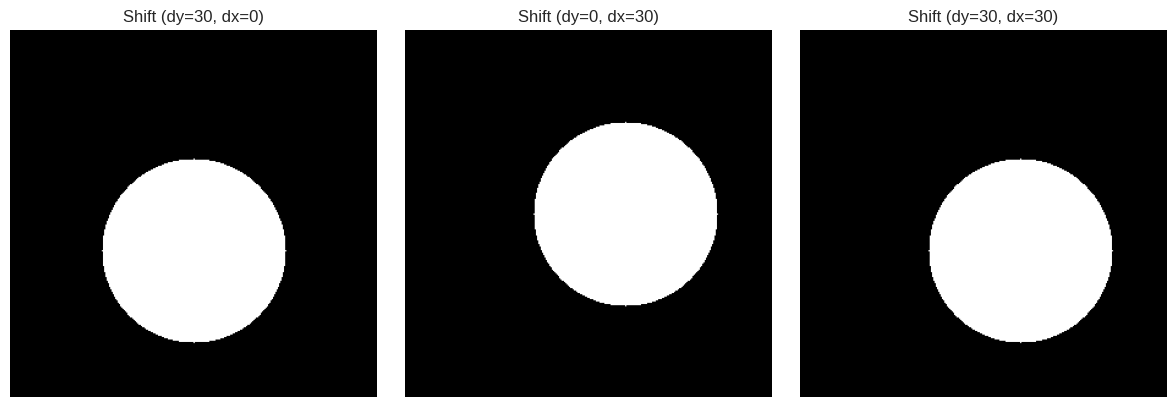

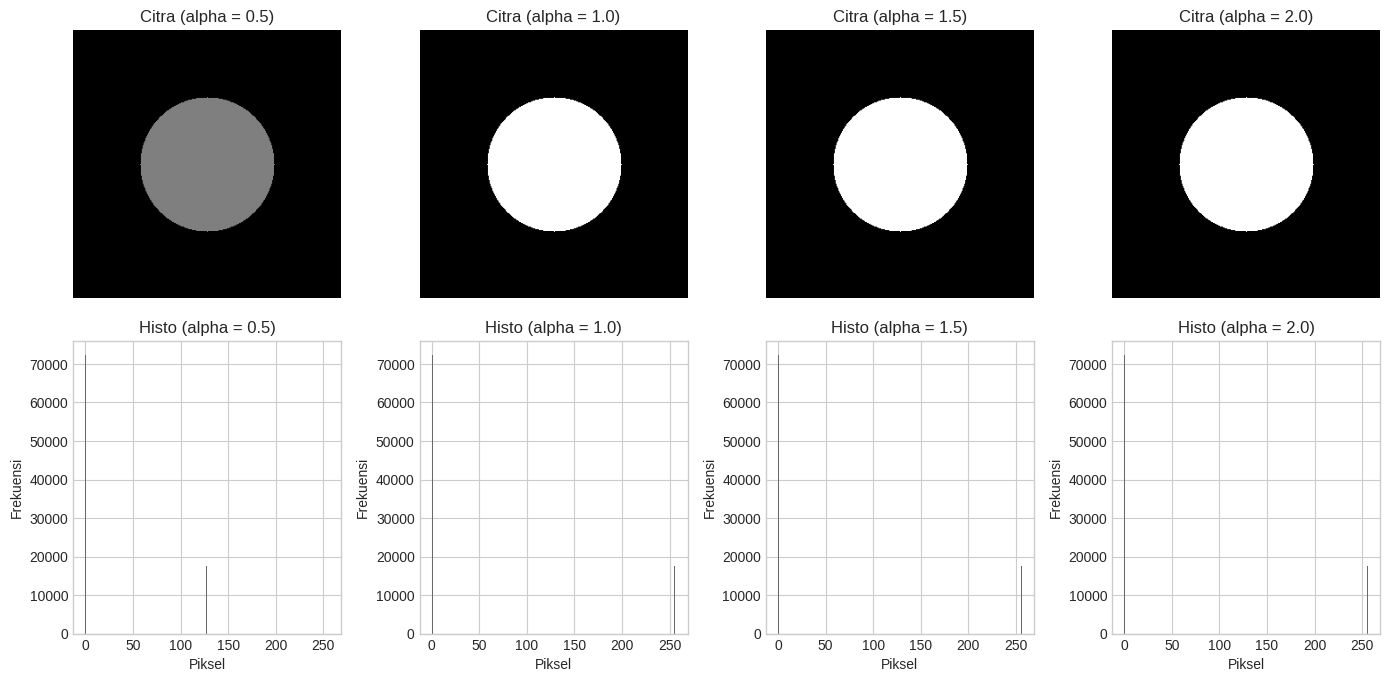


=== Memproses Bagian C: Uji Sistem Linier ===


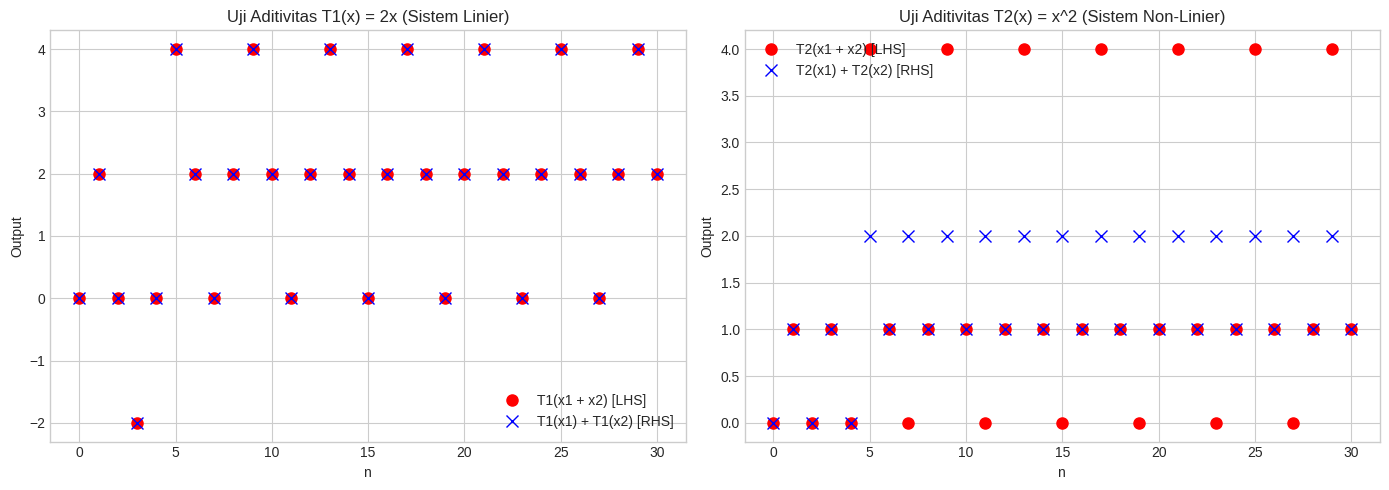


=== Seluruh Eksperimen Selesai Diproses ===


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

if 'seaborn-v0_8-whitegrid' in plt.style.available:
    plt.style.use('seaborn-v0_8-whitegrid')
else:
    plt.style.use('default')

print("=== Memproses Bagian A: Sinyal 1D ===")

n = np.arange(0, 31)
x1 = np.sin(0.5 * np.pi * n)
x2 = np.where(n >= 5, 1.0, 0.0)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Sinyal x1[n] = sin(0.5*pi*n)')
plt.xlabel('n')
plt.ylabel('Amplitudo')

plt.subplot(1, 2, 2)
plt.stem(n, x2, linefmt='g-', markerfmt='go', basefmt='r-')
plt.title('Sinyal x2[n] (Unit Step, n >= 5)')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.tight_layout()
plt.show()

y_add = x1 + x2

plt.figure(figsize=(12, 5))
plt.stem(n, x1, linefmt='b:', markerfmt='bx', label='x1[n]', basefmt=' ')
plt.stem(n, x2, linefmt='g--', markerfmt='go', label='x2[n] (Step)', basefmt=' ')
plt.stem(n, y_add, linefmt='r-', markerfmt='ro', label='y[n] = x1[n] + x2[n]', basefmt='r-')
plt.title('Penjumlahan Sinyal Diskrit x1[n] + x2[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.legend()
plt.show()

shifts = [-3, 0, 4]
plt.figure(figsize=(14, 5))
colors_fmt = ['m', 'b', 'c']

for k, color in zip(shifts, colors_fmt):
    y_shift = np.zeros_like(n, dtype=float)
    for i, ni in enumerate(n):
        idx = ni - k
        if 0 <= idx <= 30:
            y_shift[i] = x1[idx]
            
    plt.stem(n, y_shift, linefmt=f'{color}-', markerfmt=f'{color}o', label=f'Shift k = {k}', basefmt='r-')

plt.title('Perbandingan Penggeseran Sinyal x1[n-k]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.legend()
plt.show()

# A.4 Operasi Amplifikasi Sinyal
alphas = [0.5, 1, 2, -1]
plt.figure(figsize=(14, 7))

for i, alpha in enumerate(alphas, 1):
    y_amp = alpha * x1
    plt.subplot(2, 2, i)
    plt.stem(n, x1, linefmt='b:', markerfmt='bx', label='Asli', basefmt=' ')
    plt.stem(n, y_amp, linefmt='m-', markerfmt='mo', label=f'alpha = {alpha}', basefmt='r-')
    plt.title(f'Amplifikasi dengan alpha = {alpha}')
    plt.xlabel('n')
    plt.ylabel('Amplitudo')
    plt.legend()

plt.tight_layout()
plt.show()


print("\n=== Memproses Bagian B: Citra 2D ===")

img1 = np.zeros((300, 300), dtype=np.uint8)
cv2.circle(img1, (150, 150), 75, 255, -1)  # Objek lingkaran putih di tengah

img2 = np.zeros((300, 300), dtype=np.uint8)
for i in range(300):
    img2[:, i] = int(i * 255 / 300)  # Gradien kecerahan horizontal

print(f"Properti Citra Asli -> Ukuran: {img1.shape} | Tipe Data: {img1.dtype}")
print(f"Nilai Piksel -> Min: {img1.min()}, Max: {img1.max()}")

img_add_clip = cv2.add(img1, img2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title('Citra 1 (Objek)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray', vmin=0, vmax=255)
plt.title('Citra 2 (Gradien)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_add_clip, cmap='gray', vmin=0, vmax=255)
plt.title('Hasil Penjumlahan (Clipping)')
plt.axis('off')
plt.show()

rows, cols = img1.shape
translations = [(30, 0), (0, 30), (30, 30)]

plt.figure(figsize=(12, 4))
for i, (di, dj) in enumerate(translations, 1):
    # Matriks Translasi M = [[1, 0, tx], [0, 1, ty]] -> dj=tx, di=ty
    M = np.float32([[1, 0, dj], [0, 1, di]])
    img_shifted = cv2.warpAffine(img1, M, (cols, rows))
    
    plt.subplot(1, 3, i)
    plt.imshow(img_shifted, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Shift (dy={di}, dx={dj})')
    plt.axis('off')
    
plt.tight_layout()
plt.show()

alphas_img = [0.5, 1.0, 1.5, 2.0]
plt.figure(figsize=(14, 7))

for i, alpha in enumerate(alphas_img):
    img_amp = np.clip(alpha * img1.astype(float), 0, 255).astype(np.uint8)
    
    # Render Citra Hasil
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_amp, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Citra (alpha = {alpha})')
    plt.axis('off')
    
    # Render Histogram Koresponden
    plt.subplot(2, 4, i + 5)
    plt.hist(img_amp.ravel(), bins=256, range=[0, 256], color='dimgray')
    plt.title(f'Histo (alpha = {alpha})')
    plt.xlabel('Piksel')
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print("\n=== Memproses Bagian C: Uji Sistem Linier ===")

def T1(x): return 2 * x
def T2(x): return x ** 2

lhs_t1 = T1(x1 + x2)
rhs_t1 = T1(x1) + T1(x2)

lhs_t2 = T2(x1 + x2)
rhs_t2 = T2(x1) + T2(x2)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(n, lhs_t1, 'ro', markersize=8, label='T1(x1 + x2) [LHS]')
plt.plot(n, rhs_t1, 'bx', markersize=8, label='T1(x1) + T1(x2) [RHS]')
plt.title('Uji Aditivitas T1(x) = 2x (Sistem Linier)')
plt.xlabel('n')
plt.ylabel('Output')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(n, lhs_t2, 'ro', markersize=8, label='T2(x1 + x2) [LHS]')
plt.plot(n, rhs_t2, 'bx', markersize=8, label='T2(x1) + T2(x2) [RHS]')
plt.title('Uji Aditivitas T2(x) = x^2 (Sistem Non-Linier)')
plt.xlabel('n')
plt.ylabel('Output')
plt.legend()

plt.tight_layout()
plt.show()

print("\n=== Seluruh Eksperimen Selesai Diproses ===")